In [15]:
import pandas as pd

df = pd.read_csv('../data/q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("Task 1: Feature Engineering Confirmation")
display(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head())

Task 1: Feature Engineering Confirmation


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


In [19]:

df = df.sort_values('transaction_date').reset_index(drop=True)

X = df.drop(columns=['transaction_date', 'items_sold'])
y = df['items_sold']

split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {len(X_train)} rows | Test set: {len(X_test)} rows")

Training set: 960 rows | Test set: 240 rows


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = X.columns.drop(cat_features).tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

print("Preprocessing Pipeline Defined.")

Preprocessing Pipeline Defined.


--- Model Evaluation Metrics ---
Linear Regression: RMSE = 27.12, MAE = 21.05
Random Forest: RMSE = 30.86, MAE = 24.05


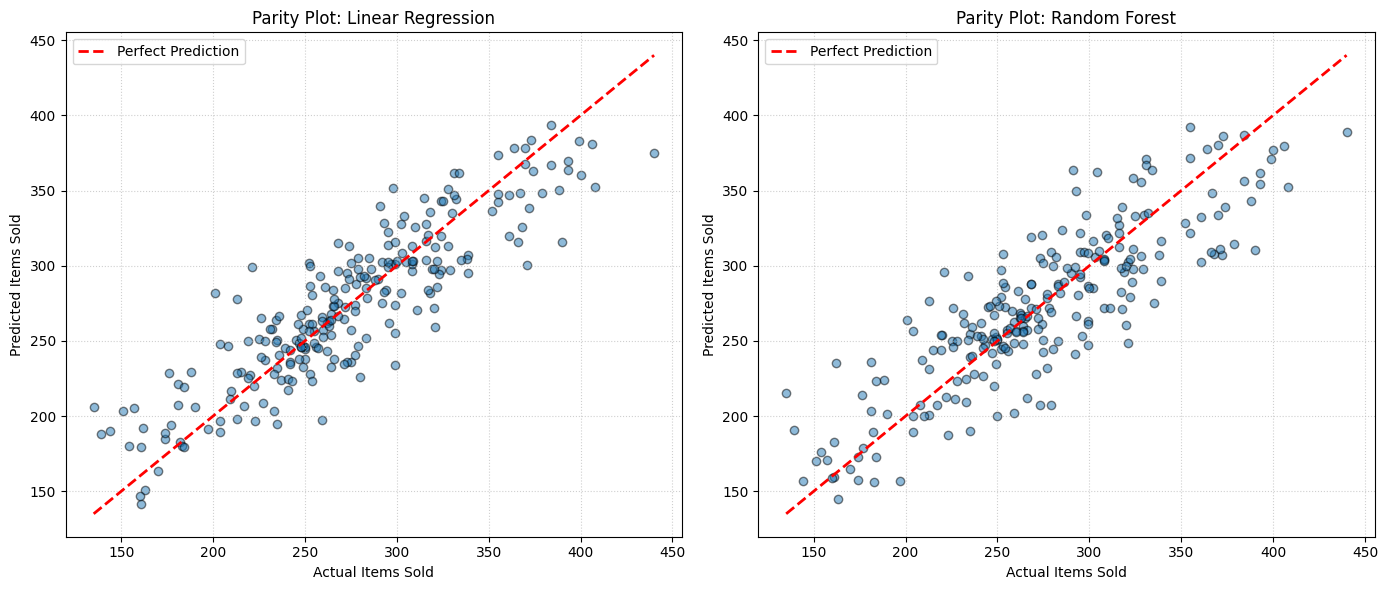


--- Top 5 Most Influential Features (Random Forest) ---


,Feature,Importance
2,is_festival,0.173073
18,store_size_small,0.171929
15,location_type_urban,0.112123
6,day_of_week,0.085299
1,is_weekend,0.064699


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np


pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)


models = [('Linear Regression', pipeline_lr), ('Random Forest', pipeline_rf)]
results = {}

print("--- Model Evaluation Metrics ---")
for name, pipeline in models:
    preds = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results[name] = preds # Store for plotting
    print(f"{name}: RMSE = {rmse:.2f}, MAE = {mae:.2f}")


plt.figure(figsize=(14, 6))

for i, (name, pipeline) in enumerate(models, 1):
    plt.subplot(1, 2, i)
    plt.scatter(y_test, results[name], alpha=0.5, edgecolors='k')
    

    line_coords = [y_test.min(), y_test.max()]
    plt.plot(line_coords, line_coords, 'r--', lw=2, label='Perfect Prediction')
    
    plt.title(f'Parity Plot: {name}')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

ohe_feature_names = pipeline_rf.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)
all_feature_names = np.concatenate([num_features, ohe_feature_names])

importances = pipeline_rf.named_steps['regressor'].feature_importances_

feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

print("\n--- Top 5 Most Influential Features (Random Forest) ---")
display(feat_imp_df.head(5))